In [1]:
import torch
import numpy
import matplotlib.pyplot as plt

# LFY032
## Föreläsning 3, del 2
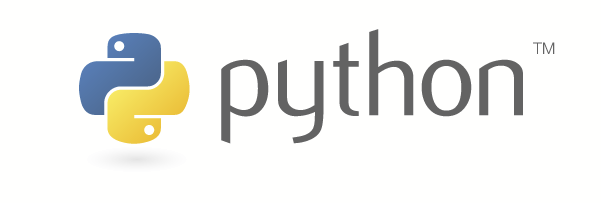
Fredrik Skärberg

# Bildigenkänning med klassificering

## MNIST
![MNIST2](../images/mnist.png)

<img src="../images/mnist_2digits.png"/>

### Dataformat
* $ 28 \times 28$ pixlar
* Gråskala, värden mellan 0 och 1

In [43]:
import torchvision
import torch
import matplotlib.pyplot as plt

### Läsa in data via torchvision

In [44]:
mnist = torchvision.datasets.MNIST('../datasets', train=True, download=True, transform=torchvision.transforms.ToTensor())

In [45]:
print(len(mnist))

60000


In [46]:
mnist.classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

### Printa fördelningen av siffror

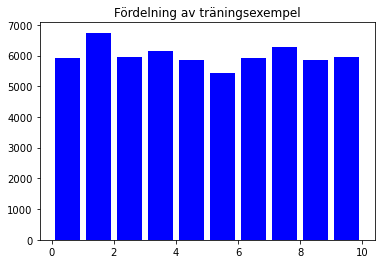

In [47]:
siffror = []
for i in range(len(mnist)):
    siffror.append(mnist[i][1])
plt.hist(siffror, bins=10, range=(0, 10), align='mid', rwidth=0.8, color='blue', label='Siffror')
plt.title('Fördelning av träningsexempel')
plt.show()

In [48]:
#Skapa en träningsinladdare.
train_loader = torch.utils.data.DataLoader(mnist, batch_size=128)

#En iterator
examples = iter(train_loader)


`iter(object)` är en funktion som skapar en **iterator**. 

En iterator kan traversera igenom en samling objekt, ett i taget, med hjälp av funktionen `next(iter)`.

Till skillnad från en lista som går att indexera, t.ex kan vi plocka ut det 5e elementet, så kan alltså en iterator bara hämta nästa element.

In [49]:
# Varje element i train_loader är en tupel med en samling (batch) bilder tillsammans 
# med en samling heltal som säger vilka siffror som finns i bilderna.
bilder, siffror = next(examples)

In [50]:
type(bilder)

torch.Tensor

In [51]:
type(siffror)

torch.Tensor

In [53]:
bilder.shape

torch.Size([128, 1, 28, 28])

In [54]:
siffror.shape

torch.Size([128])

Både `bilder` och `siffror` är s.k. **tensorer**. En tensor är en lista av listor (av listor (av listor) osv). Vi går igenom detta strax.

### En en-dimensionell tensor är en lista (eller en vektor)

#### Vektor
  $$ \left(x_1, x_2, ..., x_n\right) $$

#### Python
```python
[ x1, x2, ..., xn ]
```

### En två-dimensionell tensor är en lista av listor (eller en matris)

#### Matris
  $$ \begin{pmatrix}
   m_{11} & m_{12} \\
   m_{21} & m_{22}
   \end{pmatrix} $$

#### Python
```python
[[m11, m12], [m21, m22]]
```
eller om vi skriver ut koden lite mer läsbart
```python
[
    [m11, m12],
    [m21, m22]
]
```

In [57]:
matris = [["rad 1 kolumn 1", "rad 1 kolumn 2"], ["rad 2 kolumn 1", "rad 2 kolumn 2"]]
matris[0][0]

'rad 1 kolumn 1'

### En tre-dimensionell tensor är en lista av listor av listor

  #### 3-dimensionell tensor
  $$ 
  \begin{pmatrix}
   \begin{pmatrix}
   m_{111} & m_{112} \\
   m_{121} & m_{122}
  \end{pmatrix} & \begin{pmatrix}
   m_{211} & m_{212} \\
   m_{221} & m_{222}
  \end{pmatrix} &
   \begin{pmatrix}
   m_{311} & m_{312} \\
   m_{321} & m_{322}
  \end{pmatrix}
  \end{pmatrix} 
   $$

```
[
    [
        [m111, m112],
        [m121, m122]
    ],
    [
        [m211, m212],
        [m221, m222]
    ],
    [
        [m311, m312],
        [m321, m322]
    ],
]
```

### torch.Tensor (och numpy.ndarray)

För att kunna jobba smidigare med listor av listor så implementerar många moduler en speciell datatyp för detta.

Det mest välkända exemplet är `numpy` där typen `ndarray` (läs n-dimensionell array) gör det enkelt att arbete med dessa objekt. Många andra paket baserar sina metoder och syntax på numpy, t.ex `torch.Tensor`.

In [58]:
x = torch.Tensor([[11, 12], [21, 22]])
x

tensor([[11., 12.],
        [21., 22.]])

In [59]:
# Rad 1
x[0, :]

tensor([11., 12.])

In [61]:
# Rad 1 Kolumn 1
x[0, 0]

tensor(11.)

In [62]:
# Kolumn 1
x[:, 0]

tensor([11., 21.])

# Metoder på tensorer (och ndarrays)

In [63]:
# Summera alla element
x.sum()

tensor(66.)

In [64]:
# Summera alla element och ge tillbaka en float
x.sum().item()

66.0

In [66]:
# Summera alla element och ge tillbaka en numpy array
x.sum().numpy()

array(66., dtype=float32)

In [67]:
# Exponentiera alla element
torch.exp(x)

tensor([[5.9874e+04, 1.6275e+05],
        [1.3188e+09, 3.5849e+09]])

In [69]:
# Hitta index för största elementen i varje rad
x = torch.Tensor([
    [11, 12], 
    [21, 22]
])
torch.argmax(x, axis=1)

tensor([1, 1])

### Vi kan skapa tensorer, likt som vi gjorde med numpy.

In [79]:
zeros = torch.zeros(2, 3)
print(zeros)

ones = torch.ones(2, 3)
print(ones)

#torch.manual_seed(12) #Sätt en slumpgenerator
random = torch.rand(2, 3)
print(random)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[0.4339, 0.8813, 0.3216],
        [0.2604, 0.2566, 0.1872]])


### Mer information om tensorer för den som vill fördjupa sig:

https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html

https://pytorch.org/tutorials/beginner/introyt/tensors_deeper_tutorial.html

In [80]:
mnist = torchvision.datasets.MNIST('../datasets', train=True, download=True, transform=torchvision.transforms.ToTensor())
train_loader = torch.utils.data.DataLoader(mnist, batch_size=128)
examples = iter(train_loader)

In [81]:
bilder, siffror = next(examples)
print(bilder.shape)
print(siffror.shape)

torch.Size([128, 1, 28, 28])
torch.Size([128])


tensor(0.)
tensor(0.)
tensor(0.)


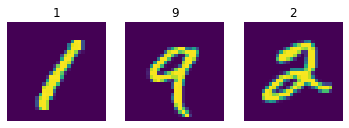

In [83]:
# Visa några exempel

# zip(bilder[:3], siffror[:3]) skapar en lista av tupler [(bild1, siffra1), (bild2, siffra2), ...]
for n, (bild, siffra) in enumerate(zip(bilder[3:6], siffror[3:6])):
    plt.subplot(1, 3, n + 1)
    plt.imshow(bild[0])
    plt.axis("off")
    plt.title(siffra.item())
    print(bild[0,0,0])

# Neuralt nät för bildklassificering

<img src="../images/mnistmodel_small.png" width=50%/>

Sista lagret i nätverket innehåller 10 neuroner som alla resulterar i ett flyttal. Vi har alltså en vektor med längden 10 som utdata från modellen, t.ex $[0, 0.8, 0, 0, 0, 0, 0, 0.2, 0, 0]$.

$$
\left[ 0.0, \underbrace{0.8}_{\text{sannolikhet för siffran 1}}, 0, 0, 0, 0, 0, \underbrace{0.2}_{\text{sannolikhet för siffran 7}}, 0, 0\right]
$$

In [85]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(28*28, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10),
    torch.nn.LogSoftmax(dim=1) # Tvinga talen i sista lagret att ha värden mellan 0.0 och 1.0
)

### Softmax
För att kunna göra en sannolikhetstolkning av prediktionen från det neurala nätet så tvingar vi talen i sista lagret att bilda en distribution, dvs att alla tal är mellan 0 och 1 samt att summan av alla tal är 1.

Dvs. Softmax är en aktiveringsfunktion för att omvandla en vektor av råa, icke-normaliserade tal (ofta kallade logits eller scores) till en sannolikhetsdistribution.


Matematiskt uttryckt, om $\mathbf{z}$ är en vektor av råa värden och $\sigma(\mathbf{z})$ är resultatet av softmax-funktionen:

$$ \sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$



In [86]:
t = torch.Tensor([1, 2, 3, 4, 5])
p = torch.nn.functional.softmax(t, dim=0)
print(p)

tensor([0.0117, 0.0317, 0.0861, 0.2341, 0.6364])


In [88]:
p.sum()

tensor(1.)

In [89]:
model = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(28*28, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10),
    torch.nn.LogSoftmax(dim=1) # Tvinga talen i sista lagret att ha värden mellan 0.0 och 1.0
)

optimerare = torch.optim.Adam(model.parameters(), lr=0.01)

In [90]:
# Träna det neurala nätet genom att gå igenom all data
def train(omgång, model, train_loader, optimerare):
    for batch_idx, (image, digit) in enumerate(train_loader):
            output = model(image)
            loss = torch.nn.functional.nll_loss(output, digit)
            # 4 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
            optimerare.zero_grad()
            loss.backward()
            optimerare.step()
            if batch_idx % 100 == 0: # Visa information då och då
                print('Träningsomgång: {} [{}/{} ({:.0f}%)]\t Fel: {:.6f}'.format(
                    omgång, batch_idx * len(image), len(train_loader.dataset),
                    100. * batch_idx / len(train_loader), loss.item()))

`torch.nn.functional.nll_loss` står för "Negative Log Likelihood Loss," och det används främst för klassificeringsuppgifter när du har logaritmer av sannolikheterna som modellens utdata. Här är en förklaring av funktionen:

Matematiskt kan det uttryckas som:

$$
\text{NLLLoss}(\mathbf{y}, \mathbf{t}) = -\frac{1}{N} \sum_{i=1}^{N} \log(y_{i, t_i})
$$

där:
- $\mathbf{y}$ är logaritmen av sannolikheterna för varje klass (modellens utdata).
- $\mathbf{t}$ är vektorn av sanna klassetiketter för varje instans i batchen.
- $N$ är antalet instanser i batchen.

Dvs. desto närmare vi är 1 för korrekt klass, desto mindre loss kommer vi att ha.

In [91]:
for i in range(4):
    train(i, model, train_loader, optimerare)

Träningsomgång: 0 [0/60000 (0%)]	 Fel: 2.310688
Träningsomgång: 0 [12800/60000 (21%)]	 Fel: 0.247005
Träningsomgång: 0 [25600/60000 (43%)]	 Fel: 0.238663
Träningsomgång: 0 [38400/60000 (64%)]	 Fel: 0.150660
Träningsomgång: 0 [51200/60000 (85%)]	 Fel: 0.333105
Träningsomgång: 1 [0/60000 (0%)]	 Fel: 0.102525
Träningsomgång: 1 [12800/60000 (21%)]	 Fel: 0.214829
Träningsomgång: 1 [25600/60000 (43%)]	 Fel: 0.075994
Träningsomgång: 1 [38400/60000 (64%)]	 Fel: 0.088794
Träningsomgång: 1 [51200/60000 (85%)]	 Fel: 0.111075
Träningsomgång: 2 [0/60000 (0%)]	 Fel: 0.122579
Träningsomgång: 2 [12800/60000 (21%)]	 Fel: 0.159763
Träningsomgång: 2 [25600/60000 (43%)]	 Fel: 0.141509
Träningsomgång: 2 [38400/60000 (64%)]	 Fel: 0.111219
Träningsomgång: 2 [51200/60000 (85%)]	 Fel: 0.150603
Träningsomgång: 3 [0/60000 (0%)]	 Fel: 0.101522
Träningsomgång: 3 [12800/60000 (21%)]	 Fel: 0.110502
Träningsomgång: 3 [25600/60000 (43%)]	 Fel: 0.245458
Träningsomgång: 3 [38400/60000 (64%)]	 Fel: 0.099712
Träningsomgån

### Ladda in testdata och prediktera på. Viktigt att evaluera modell på data den inte är tränad på!

In [92]:
mnist_test = torchvision.datasets.MNIST('./datasets', train=False, download=True, transform=torchvision.transforms.ToTensor())
test_loader = torch.utils.data.DataLoader(mnist_test, batch_size=1)
examples = iter(test_loader)

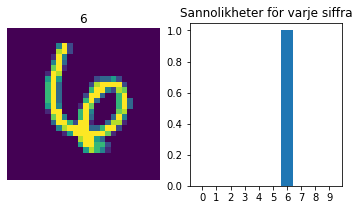

Rätt siffra: 6 Prediktion: 6 


In [115]:
for _ in range(1):
    bild, siffra = next(examples)
    ut = model(bild)
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title(ut.argmax(dim=1).item())
    plt.imshow(bild[0][0])
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Sannolikheter för varje siffra")
    plt.bar(range(10), torch.exp(ut[0]).detach().numpy())
    plt.xticks(range(10))
    plt.show()
    print(f"Rätt siffra: {siffra.item()} Prediktion: {ut.argmax(dim=1).item()} ")


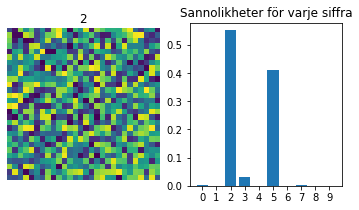

In [121]:
bild = torch.rand(1, 1, 28, 28) #slumpmässiga tal mellan 0-1.
#bild = torch.zeros(1, 1, 28, 28) # Bara nollor.
#bild = torch.ones(1, 1, 28, 28) # Bara ettor.

siffra = torch.tensor([1])

ut = model(bild)
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title(ut.argmax(dim=1).item())
plt.imshow(bild[0][0])
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Sannolikheter för varje siffra")
plt.bar(range(10), torch.exp(ut[0]).detach().numpy())
plt.xticks(range(10))
plt.show()

### Man får alltid en prediktion. Och nätverket är ofta "säker" på sitt svar även om inputen är "ingenting".

Okej det funkar ju bra att platta till en bild till en vektor och mata in till ett artificiellt neuralt nätverk. 

Men kanske måste man inte platta till en bild? Vi förlorar ju en del spatial information på detta sättet. Och såhär ser väl inte vår hjärna på en bild?

# Konvolutional neurala nätverk

* Förmodligen den mest frekvent använda formen av ett neuralt nätverk är ett CNN. Dessa nätverk opererar på matriser/vektorer (vilken storlek som helst, men framförallt på bilder...). Vilket gör att de har stora tilläpmningsområden.

* Kan ses som modeller som extraherar mönster från bilder -> och sen kopplar samman med ett ANN.

* ANN är fortfarande väldigt kraftfulla, men CNN;s har endel fördelar.

### Varför Konvolutional neurala nätverk?

#### Vad är det här en bild på?
<img src="../images/dog_flatten.png" width=50%/>

<img src="../images/dog_normal.png" width=50%/>

#### Båda är av samma bild. Har samma pixelvärden. Ena är en 1D representation och den andra en 2D representation!


#### Artificiella neurala nätverk förlorar spatiell orientering. Ser du någon skillnad mellan dessa bilder?
<img src="../images/dog_flatten_rot.png" width=50%/>

<img src="../images/dog_rot.png" width=50%/>

#### Vi ändrade bara postionen av ett par pixlar i vektorn och fick en helt annan bild. Svårt att se detta i 1D vektorn men väldigt enkelt i bilden!


* Ett annat problem med att platta till en bild till en vektor är att dimensionerna snabbt blir väldigt stora.


In [123]:
print(28*28)
print(64*64)
print(256*256)
print(512*512) #512*512. Inte ens superstor bild ger en input på 262 tusen tal som alla ska ha en vikt kopplat till sig.

784
4096
65536
262144


In [125]:
input_size = 512
model_t = torch.nn.Sequential(
    torch.nn.Flatten(),
    torch.nn.Linear(input_size**2, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 10),
    torch.nn.LogSoftmax(dim=1) # Tvinga talen i sista lagret att ha värden mellan 0.0 och 1.0
)

total_params = sum(p.numel() for p in model_t.parameters())
print(f"Number of parameters: {total_params/1e7} miljoner")

del model_t

Number of parameters: 3.3572362 miljoner


#### De två stora nackdelarna med artificiella neurala nätverk (när appliceras på bilder):

* Tappar spatial information.
* Antalet parametrar ökar drastiskt med bildstorlek och antalet lager.

### Ett konvolutional nerualt nätverk
<img src="../images/cnn_overview.png" width=90%/>

Convolutional neurala nätverk (CNNs):

1. **Filter(kernel) för Mönster:** CNNs använder små filter för att hitta mönster i bilder, som kan vara kanter, färger eller komplexa former.

2. **Pooling för Sammanfattning:** Efter varje filtrering använder CNNs pooling för att sammanfatta och minska informationen, vilket hjälper till att behålla viktiga mönster.

3. **Hierarkisk Inlärning:** CNNs lär sig gradvis från enkla till mer komplexa mönster, från kanter till detaljerade objekt, genom flera lager.

4. **Förbindningar för Rumslig Hierarki:** CNNs använder viktdelning och kopplingar mellan närliggande pixlar för att förstå rumsliga hierarkier i data, vilket är användbart för bildigenkänning.

5. **Slutligen, Klassificering:** Efter flera lager av filtrering och sammanfattning används fully connected layers för att göra slutgiltiga beslut, såsom att identifiera objekt i en bild.

I grund och botten är CNNs bra på att förstå och extrahera mönster i bilder, vilket gör dem mycket användbara för uppgifter som bildigenkänning och klassificering.

### Två nya koncept att ta sig an:

* Konvolution - Träningsbara filter för att hitta mönster i t ex. bilder.
* Pooling - Komprimera bilden, t ex. genom att ta maxvärdet av 4 pixlar i en ruta. 4 -> 1

### Konvolution
<img src="../images/conv_operation.gif" width=80%/>

* Multiplicera bild med ett filter(kernel) -> summera pixlar -> ny bild
* Filtret är det träningsbara

### Pooling
<img src="../images/max_pool.png" width=50%/>

* Förstärker kanter.
* Komprimerar information - > Färre vikter.

### Låt oss nu konstruera ett 2DCNN

In [126]:
kernels1 = 8
kernels2 = 8
ann_size = 64

model_cnn = torch.nn.Sequential(
    torch.nn.Conv2d(1, kernels1, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Conv2d(kernels1, kernels2, kernel_size=3, padding=1),
    torch.nn.ReLU(),
    torch.nn.MaxPool2d(kernel_size=2, stride=2),
    torch.nn.Flatten(),
    torch.nn.Linear(kernels2 * 7 * 7, ann_size),
    torch.nn.ReLU(),
    torch.nn.Linear(ann_size, 10),
    torch.nn.LogSoftmax(dim=1) # Tvinga talen i sista lagret att ha värden mellan 0.0 och 1.0
)

optimerare = torch.optim.Adam(model_cnn.parameters(), lr=0.01)

In [127]:
total_params = sum(p.numel() for p in model_cnn.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 26466


In [128]:
for i in range(2):
    train(i, model_cnn, train_loader, optimerare)

Träningsomgång: 0 [0/60000 (0%)]	 Fel: 2.310483
Träningsomgång: 0 [12800/60000 (21%)]	 Fel: 0.219109
Träningsomgång: 0 [25600/60000 (43%)]	 Fel: 0.164385
Träningsomgång: 0 [38400/60000 (64%)]	 Fel: 0.140436
Träningsomgång: 0 [51200/60000 (85%)]	 Fel: 0.288553
Träningsomgång: 1 [0/60000 (0%)]	 Fel: 0.108199
Träningsomgång: 1 [12800/60000 (21%)]	 Fel: 0.070815
Träningsomgång: 1 [25600/60000 (43%)]	 Fel: 0.077874
Träningsomgång: 1 [38400/60000 (64%)]	 Fel: 0.127089
Träningsomgång: 1 [51200/60000 (85%)]	 Fel: 0.136350


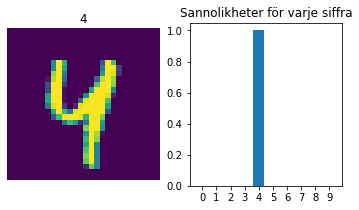

Rätt siffra: 4 Prediktion: 4 


In [148]:
for _ in range(1):
    bild, siffra = next(examples)
    ut = model_cnn(bild)
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.title(ut.argmax(dim=1).item())
    plt.imshow(bild[0][0])
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.title("Sannolikheter för varje siffra")
    plt.bar(range(10), torch.exp(ut[0]).detach().numpy())
    plt.xticks(range(10))
    plt.show()
    print(f"Rätt siffra: {siffra.item()} Prediktion: {ut.argmax(dim=1).item()} ")

tensor([4])
tensor([6])


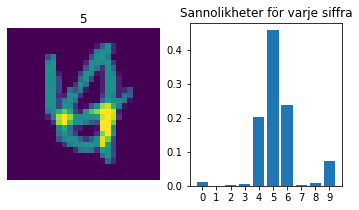

In [152]:
#Skapa en bild med två bilder
bilds = torch.zeros(1,1,28,28)
_n = 2
for _ in range(_n):
    bild, siffra = next(examples)
    bilds+=bild/2
    print(siffra)

ut = model_cnn(bilds)
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.title(ut.argmax(dim=1).item())
plt.imshow(bilds[0][0])
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Sannolikheter för varje siffra")
plt.bar(range(10), torch.exp(ut[0]).detach().numpy())
plt.xticks(range(10))
plt.show()

## Tips vid träning av neurala nätverk

### Plot över träning
<img src="../images/model_komplexitet.png" width=70%/>

* Mer träning minskar felet på träningsdatan men inte på testdatan - modellen överanpassas.
* Inget ni behöver tänka på här, men ofta tränar man med ett träningsset och samtidigt har koll på hur felet ser ut på testdata.

### Inlärningshastighetens påverkan på träningen
<img src="../images/learning_rate_vis.png" width=70%/>

* För hög inlärningshastighet gör att felet hoppar runt för mycket och vi lyckas inte konvergera.
* Kan också styra detta till viss del med större batch-size


### Större antal lager är inte alltid bättre
<img src="../images/antalet_lager.png" width=50%/>

* Desto fler lager desto svårare optimeringsproblem.

* Dropout
* BatchNormalization
* Vikt-initialisering
* Transfer Learning
* Regularization
* Augmentering av data
* Normalisering av data

### Sammanfattningsvis: Det finns många parametrar att hålla reda på vid träning av neurala nätverk.